In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score
)
from sklearn.model_selection import GridSearchCV, cross_val_score
import joblib

In [2]:
x_train_pre = joblib.load('x_train_presplit_smote.pkl')
y_train_pre = joblib.load('y_train_presplit_smote.pkl')
x_test_pre  = joblib.load('x_test_presplit_smote.pkl')
y_test_pre  = joblib.load('y_test_presplit_smote.pkl')

In [3]:
gb_model_pre = GradientBoostingClassifier(
    n_estimators=100,
    random_state=20
)
gb_model_pre.fit(x_train_pre, y_train_pre)

GradientBoostingClassifier(random_state=20)

In [4]:
gb_pred_pre = gb_model_pre.predict(x_test_pre)
gb_prob_pre = gb_model_pre.predict_proba(x_test_pre)[:, 1]
print(gb_prob_pre)

[0.74865475 0.46377285 0.42530977 0.47795302 0.84168631 0.09486622
 0.39263242 0.81805877 0.62174018 0.60790112 0.36173248 0.52090238
 0.50436122 0.82417937 0.31783798 0.91484504 0.9155492  0.21707754
 0.51606605 0.4607428  0.26649175 0.20029174 0.0857523  0.09737514
 0.17268351 0.27940758 0.28721014 0.8243301  0.70177086 0.51287914
 0.17790827 0.07970703 0.13975732 0.40656011 0.68810141 0.85367851
 0.40350483 0.21551323 0.36328578 0.38739038 0.23288714 0.38458386
 0.23172325 0.4688546  0.56235175 0.69632873 0.74282076 0.40755398
 0.5520628  0.26491432 0.3255144  0.78186646 0.78289484 0.88723609
 0.8551548  0.41774438 0.64498624 0.24822207 0.33667438 0.49592644
 0.14850786 0.77209885 0.24655946 0.21792395 0.36307156 0.65939051
 0.79811228 0.43880305 0.35942106 0.61554334 0.08773494 0.84058187
 0.51944709 0.25617267 0.90359707 0.92778867 0.87211438 0.48608812
 0.79428415 0.66197894 0.71274813 0.24532169 0.42171331 0.61387431
 0.142932   0.65631523 0.69233439 0.57137903 0.94828438 0.8596

In [5]:
gb_accuracy_pre = accuracy_score(y_test_pre, gb_pred_pre)
print("Gradient Boosting Accuracy (Pre-split SMOTE):", round(gb_accuracy_pre, 4))

Gradient Boosting Accuracy (Pre-split SMOTE): 0.8571


In [6]:
print(classification_report(y_test_pre, gb_pred_pre))

              precision    recall  f1-score   support

           0       0.85      0.86      0.86       339
           1       0.86      0.85      0.86       340

    accuracy                           0.86       679
   macro avg       0.86      0.86      0.86       679
weighted avg       0.86      0.86      0.86       679



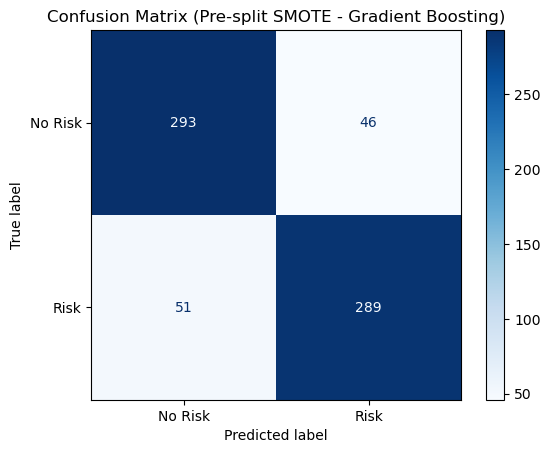

In [7]:
ConfusionMatrixDisplay.from_predictions(
    y_test_pre, gb_pred_pre,
    display_labels=['No Risk', 'Risk'],
    cmap='Blues'
)
plt.title("Confusion Matrix (Pre-split SMOTE - Gradient Boosting)")
plt.show()

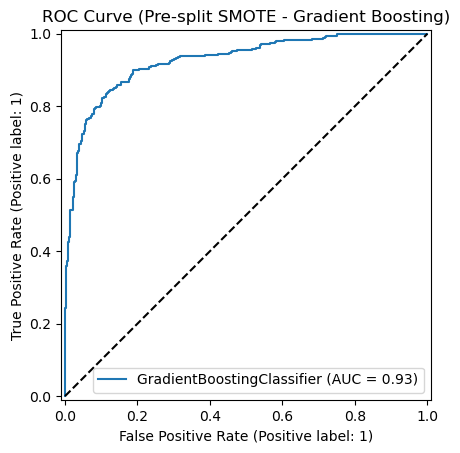

ROC-AUC Score: 0.9266


In [8]:
RocCurveDisplay.from_estimator(gb_model_pre, x_test_pre, y_test_pre)
plt.title('ROC Curve (Pre-split SMOTE - Gradient Boosting)')
plt.plot([0, 1], [0, 1], 'k--')
plt.show()

print('ROC-AUC Score:', roc_auc_score(y_test_pre, gb_prob_pre).round(4))

In [9]:
feature_names_pre = joblib.load('feature_names_presplit_smote.pkl')
n_importances = len(gb_model_pre.feature_importances_)
print("x_train_pre shape:", x_train_pre.shape)


x_train_pre shape: (2713, 28)


In [10]:

if len(feature_names_pre) == n_importances:
    labels = feature_names_pre
else:
    labels = [f"feature_{i}" for i in range(n_importances)]

feature_importance_pre = pd.DataFrame({
    "Feature": labels,
    "Importance": gb_model_pre.feature_importances_
})

feature_importance_pre = feature_importance_pre.sort_values(by="Importance", ascending=False)
print(feature_importance_pre.to_string(index=False))

 Feature  Importance
       9    0.124812
      12    0.099840
      13    0.081967
      24    0.061880
      10    0.058095
      25    0.051162
      18    0.047047
      19    0.043468
      21    0.042902
      14    0.037093
       6    0.036531
       7    0.033540
      23    0.032064
      11    0.030635
       8    0.027037
       0    0.025331
      20    0.024330
      27    0.023797
      15    0.023663
      22    0.021890
      26    0.019549
      16    0.017635
      17    0.015436
       1    0.009754
       4    0.009583
       2    0.000596
       3    0.000364
       5    0.000000


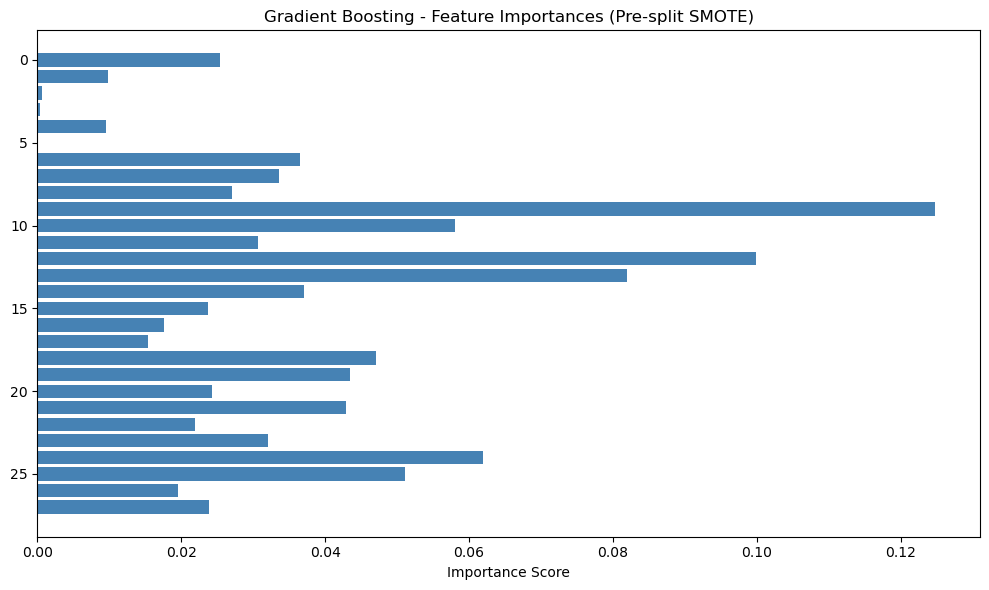

In [11]:
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_pre["Feature"], feature_importance_pre["Importance"], color="steelblue")
plt.xlabel("Importance Score")
plt.title("Gradient Boosting - Feature Importances (Pre-split SMOTE)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [12]:
train_pred_pre = gb_model_pre.predict(x_train_pre)
train_accuracy_pre = accuracy_score(y_train_pre, train_pred_pre)
print("Train Accuracy:", round(train_accuracy_pre, 4))
print("Test Accuracy :", round(gb_accuracy_pre, 4))

Train Accuracy: 0.9167
Test Accuracy : 0.8571


In [13]:
precision_pre = precision_score(y_test_pre, gb_pred_pre)
recall_pre    = recall_score(y_test_pre, gb_pred_pre)
f1_pre        = f1_score(y_test_pre, gb_pred_pre)

print("Precision:", round(precision_pre, 4))
print("Recall   :", round(recall_pre, 4))
print("F1 Score :", round(f1_pre, 4))

Precision: 0.8627
Recall   : 0.85
F1 Score : 0.8563


In [14]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2]
}

grid_search_pre = GridSearchCV(
    GradientBoostingClassifier(random_state=20),
    param_grid, cv=5, scoring='roc_auc', n_jobs=-1
)
grid_search_pre.fit(x_train_pre, y_train_pre)

GridSearchCV(cv=5, estimator=GradientBoostingClassifier(random_state=20),
             n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.1, 0.2],
                         'max_depth': [3, 5, 7],
                         'n_estimators': [100, 200, 300]},
             scoring='roc_auc')

In [15]:
print("Best Params:", grid_search_pre.best_params_)
best_model_pre = grid_search_pre.best_estimator_

Best Params: {'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 300}


In [16]:
best_pred_pre = best_model_pre.predict(x_test_pre)
best_prob_pre = best_model_pre.predict_proba(x_test_pre)[:, 1]
print("Best Model Accuracy:", round(accuracy_score(y_test_pre, best_pred_pre), 4))
print("Best Model ROC-AUC :", roc_auc_score(y_test_pre, best_prob_pre).round(4))

Best Model Accuracy: 0.9367
Best Model ROC-AUC : 0.9811


In [17]:
cv_scores_pre = cross_val_score(gb_model_pre, x_train_pre, y_train_pre, cv=5, scoring='roc_auc')
print("CV ROC-AUC Scores:", cv_scores_pre.round(4))
print("Mean:", cv_scores_pre.mean().round(4), "| Std dev:", cv_scores_pre.std().round(4))

CV ROC-AUC Scores: [0.9244 0.9259 0.9082 0.9269 0.9114]
Mean: 0.9194 | Std dev: 0.0079


In [18]:
joblib.dump(gb_model_pre, 'gradientboosting_model_presplit_smote.pkl')
print("Model saved.")

Model saved.
